# XGBOOST

In [92]:
# import potrebnych kniznic a konfiguracia notebooku

import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from xgboost import XGBRegressor
import shap

import functions_xgboost
importlib.reload(functions_xgboost)
from functions_xgboost import hyperparameters_tuning, make_features, extract_tree_structure, trace_path_for_observation, rolling_forecast_xgb

import cred
importlib.reload(cred)
from cred import DATA_PATH_CRED

import functions_general
importlib.reload(functions_general)
from functions_general import forecast_plot

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


Importy uspesne.


In [36]:
# konfiguracia a stiahnutie dat
main_dir = Path(DATA_PATH_CRED)
data_mod = "data_mod.csv"
pp_orig = "data.xlsx"
DATA_PATH_DATA_MOD  = main_dir / data_mod
DATA_PATH_DATA = main_dir / pp_orig
SHEET_NAME_PP = "pp"
SHEET_NAME_EXOG = "exog"
TEST_SIZE = 24
RANDOM_STATE = 24
TARGET_VAR = "pp_sa_ca_jd"

df_raw = pd.read_csv(DATA_PATH_DATA_MOD)
df_raw["datum"] = pd.to_datetime(df_raw["datum"])
df_raw = df_raw.set_index("datum").sort_index()
df_raw = df_raw.asfreq("MS")
df = df_raw.copy()

df_pp = pd.read_excel(DATA_PATH_DATA,SHEET_NAME_PP)
df_pp = df_pp.set_index("datum").sort_index()
df_pp = df_pp.asfreq("MS")


In [37]:
#definovanie features, train/test vzorka
exog_cols = df.drop(columns=[TARGET_VAR,"pp_nonsa","pp_sa_orig"])
features = make_features(
    data=df,
    target=TARGET_VAR,
    exog_cols=exog_cols,
    target_lags=(1, 2, 3, 6, 12),
    exog_lags=(1,)
)

X = features.drop(columns = [TARGET_VAR, "pp_sa_ca_jd_lag1"])
y = features[TARGET_VAR]

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print(f"Trenovacia mnozina: {y_train.index.min().date()} az {y_train.index.max().date()} ({len(y_train)} obs.)")
print(f"Testovacia mnozina: {y_test.index.min().date()} az {y_test.index.max().date()} ({len(y_test)} obs.)")


Trenovacia mnozina: 2001-02-01 az 2023-12-01 (275 obs.)
Testovacia mnozina: 2024-01-01 az 2025-12-01 (24 obs.)


In [38]:
grid_search, best_params = hyperparameters_tuning(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Najlepsie parametre z Random Search: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 1, 'colsample_bytree': 0.7}
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Finalne parametre po Grid Search: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.0025, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'reg_alpha': 0.01, 'reg_lambda': 1, 'subsample': 0.6}


In [45]:
cv_results = pd.DataFrame(grid_search.cv_results_)

depth_summary = (
    cv_results
    .groupby("param_max_depth")
    .agg(
        best_rmse=("mean_test_score", lambda x: -x.max()),
        mean_rmse=("mean_test_score", lambda x: -x.mean()),
        std_cv=("std_test_score", "mean"),
        n_models=("mean_test_score", "count")
    )
    .reset_index()
    .sort_values("best_rmse")
)

depth_summary

,param_max_depth,best_rmse,mean_rmse,std_cv,n_models
2,5,3.728169,3.743703,1.082037,27
0,3,3.729493,3.751754,1.063940,27
1,4,3.729728,3.745369,1.075837,27


In [46]:
init_train_size = len(y) - TEST_SIZE
last_train_value = float(df_pp[TARGET_VAR].iloc[init_train_size - 1])


In [50]:
init_train_size = len(y) - TEST_SIZE
last_train_value = last_train_value
results_xgboost, xg_last_model = rolling_forecast_xgb(
    X=X,
    y_diff=y,
    level_series=df_pp[TARGET_VAR],        
    initial_train_size=init_train_size,
    last_train_value=last_train_value,
    horizon=1,
    refit_every=1,
    objective="reg:squarederror",
    xgb_params=best_params,
)

RMSE (diferencia): 2.5047
RMSE (level, onestep rekonstrukcia): 2.5047
MAPE (level, WMAPE): 1.90%
ME (level): -0.4222


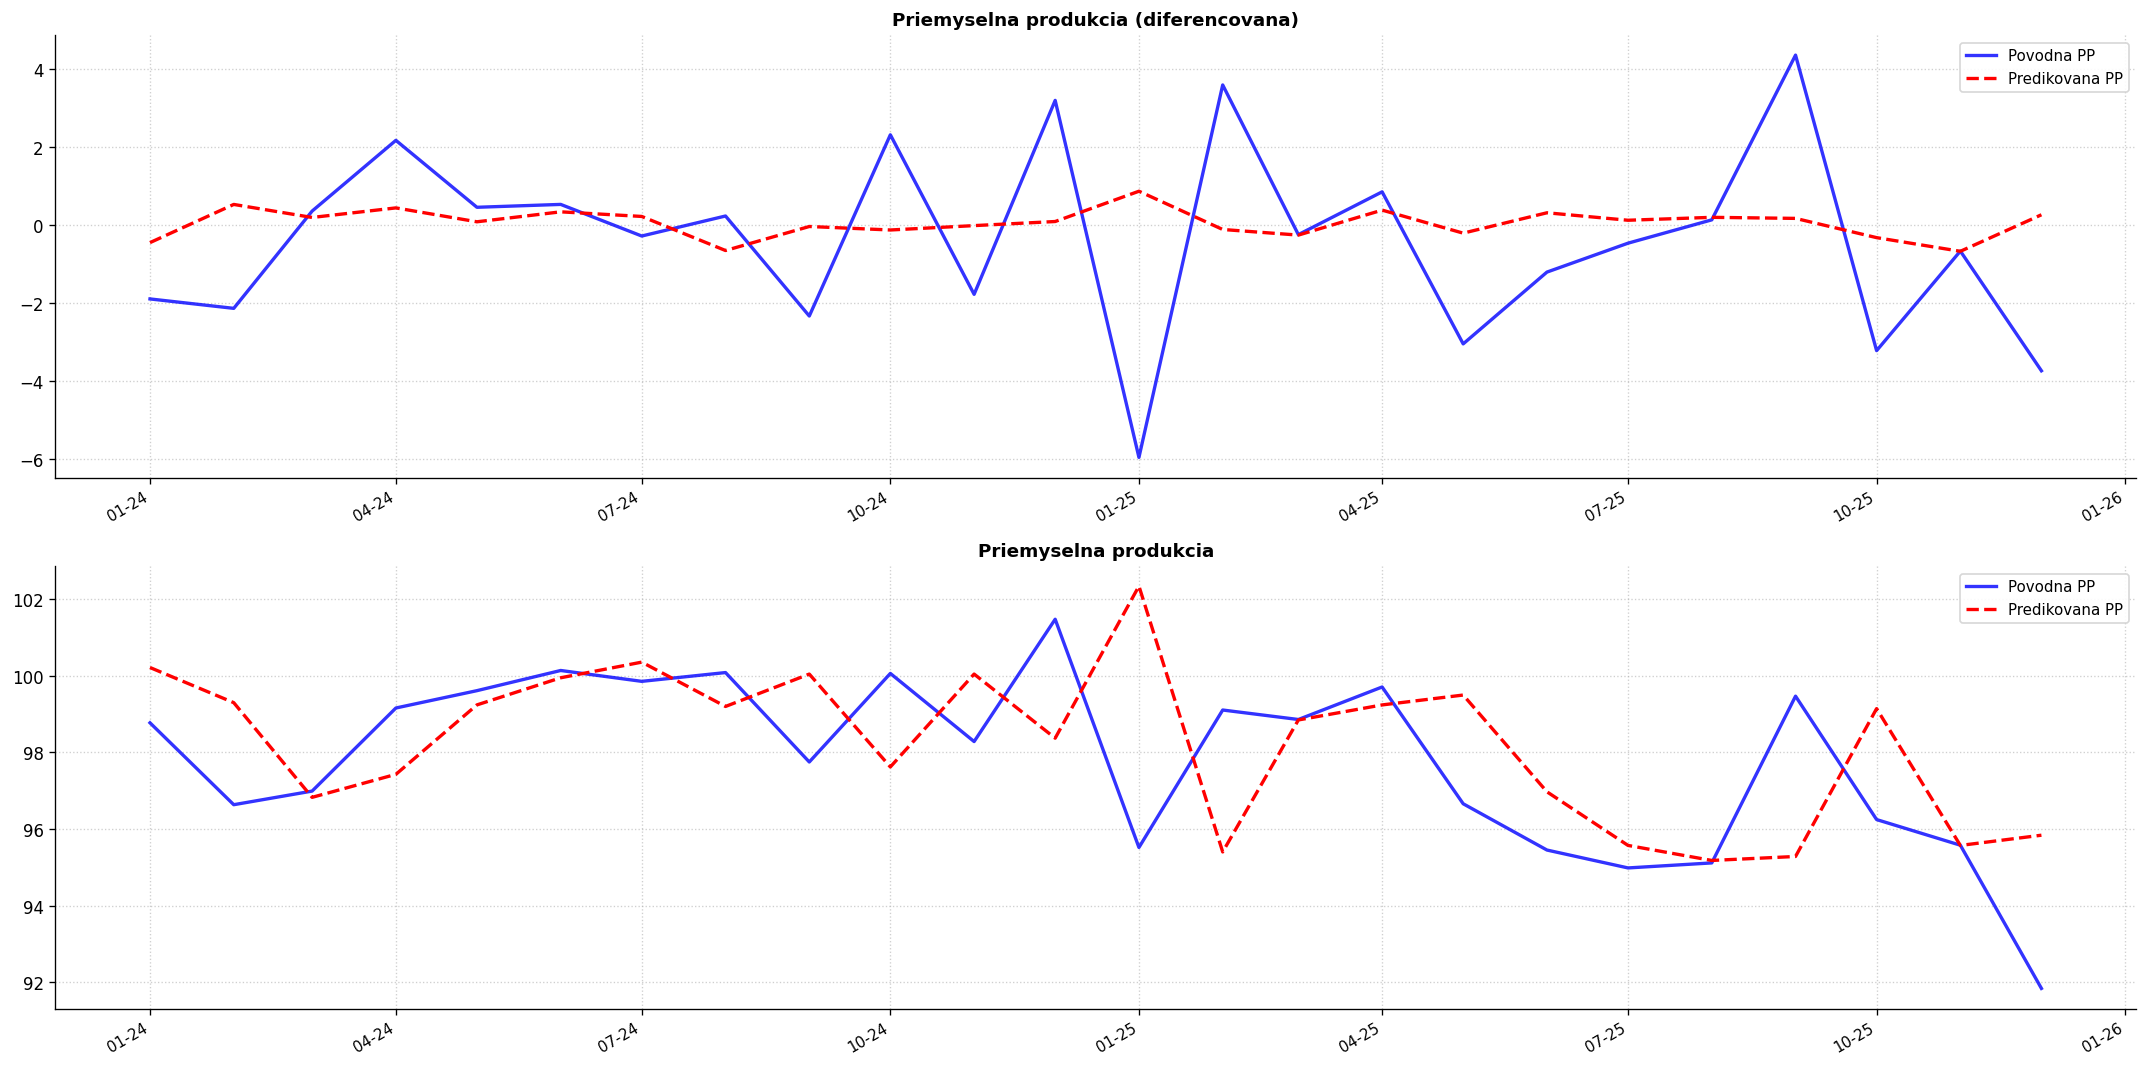

In [99]:
Y_axis = [results_xgboost["actual_diff"], results_xgboost["predicted_diff"], results_xgboost["actual_level"], results_xgboost["predicted_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Povodna PP", "Predikovana PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)", "Priemyselna produkcia"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-","--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8,1] * len(Y_axis)
fig_size = [18,9]
num_rows = 2
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols)

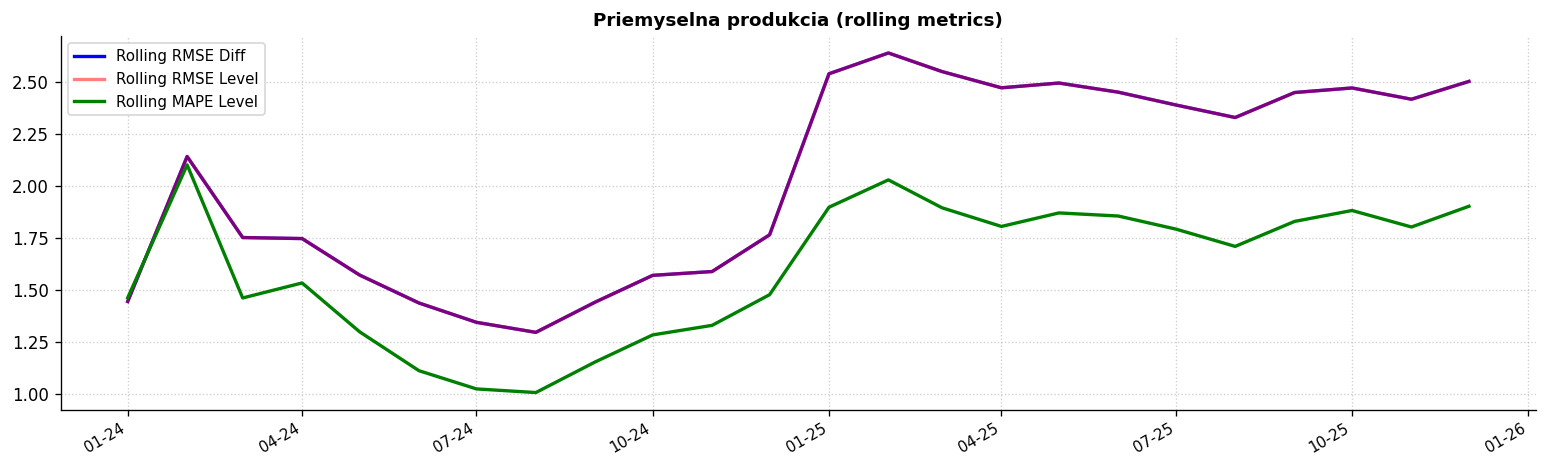

In [100]:
Y_axis = [results_xgboost["rolling_rmse_diff"], results_xgboost["rolling_rmse_level"], results_xgboost["rolling_mape_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Rolling RMSE Diff", "Rolling RMSE Level", "Rolling MAPE Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1, 0.5, 1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

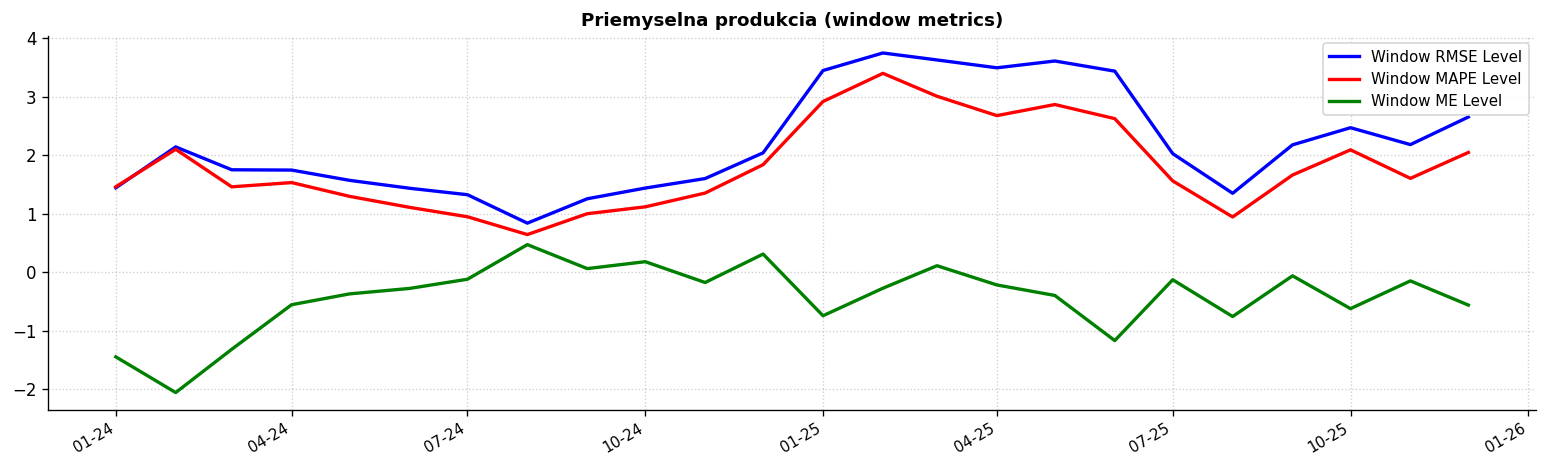

In [107]:
Y_axis = [results_xgboost["window6_rmse_level"], results_xgboost["window6_mape_level"], results_xgboost["window6_me_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Window RMSE Level", "Window MAPE Level", "Window ME Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (window metrics)"]
colors = ["#0000FF", "#FF0000", "#008000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

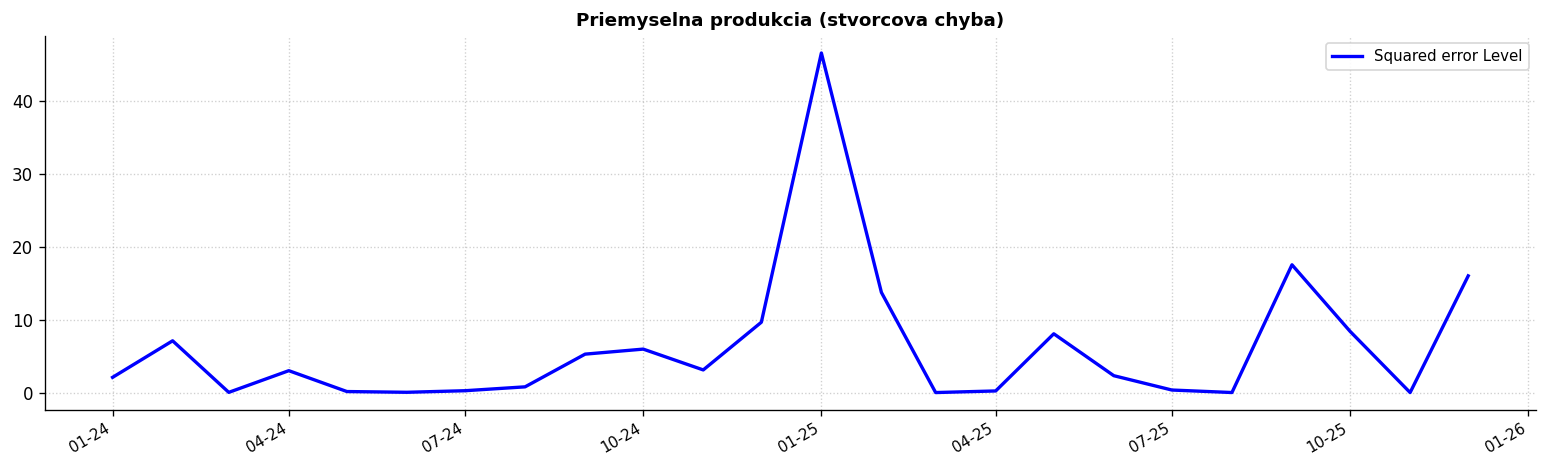

In [106]:
Y_axis = [results_xgboost["sq_error_level"]]
X_axis = [results_xgboost.index] * len(Y_axis)
labels = ["Squared error Level"] * len(Y_axis)
titles = ["Priemyselna produkcia (stvorcova chyba)"]
colors = ["#0000FF"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [1] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [109]:
#shap
last_date = max(xg_last_model.keys())
xgb_model = xg_last_model[last_date]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap_summary = pd.DataFrame(shap_values, columns = X_test.columns, index = X_test.index)
mean_abs_shap = np.abs(shap_summary).mean().sort_values(ascending=False)
mean_abs_shap

expected_industry_production_lag1     0.091653
pp_sa_ca_jd_lag6                      0.057359
industry_confidence_sa_lag1           0.054161
vklady_nefinancne_podniky_lag1        0.049646
infl_cpi_lag1                         0.046736
trzby_priemysel_sa_lag1               0.038609
oil_price_eur_lag1                    0.034677
ipcv_priemysel_lag1                   0.034409
trend                                 0.034070
economic_sentiment_lag1               0.033878
pp_sa_ca_jd_lag12                     0.030338
expected_employment_lag1              0.027669
oil_europe_eur_lag1                   0.021208
current_total_demand_sa_lag1          0.020215
kurz_usd_eur_lag1                     0.017197
cdd_lag1                              0.017117
pp_sa_ca_jd_lag2                      0.015902
uvery_celkom_lag1                     0.015140
cpi_nsa_lag1                          0.014817
expected_product_prices_lag1          0.012385
oil_europe_usd_lag1                   0.012276
sh_prices_non

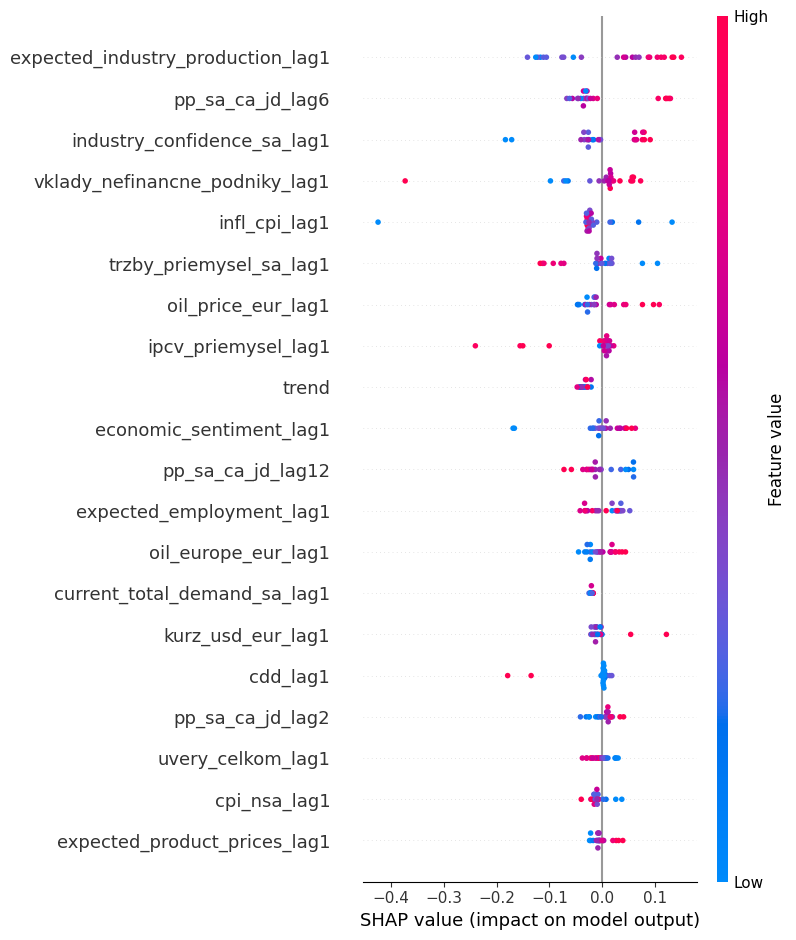

In [110]:
#graf ku shapu
shap.summary_plot(shap_values, X_test)

In [111]:
shap_rows = []

for forecast_date, xgb_model in xg_last_model.items():

    X_one = X_test.loc[[forecast_date]].copy()

    explainer = shap.TreeExplainer(xgb_model)
    shap_one = explainer(X_one)

    for feature, value, contribution in zip(X_one.columns, X_one.iloc[0].values, shap_one.values[0]):
        shap_rows.append(
            {
                "forecast_date": forecast_date,
                "feature": feature,
                "feature_value": value,
                "shap_value": contribution,
                "abs_shap_value": abs(contribution),
            }
        )

shap_long = pd.DataFrame(shap_rows)
shap_long


,forecast_date,feature,feature_value,shap_value,abs_shap_value
0,2024-01-01,pp_sa_ca_jd_lag2,-2.366972,-0.068444,0.068444
1,2024-01-01,pp_sa_ca_jd_lag3,2.416140,0.086365,0.086365
2,2024-01-01,pp_sa_ca_jd_lag6,-5.675175,-0.024686,0.024686
3,2024-01-01,pp_sa_ca_jd_lag12,8.032883,-0.048333,0.048333
4,2024-01-01,cpi_nsa_lag1,-0.307200,0.124419,0.124419
...,...,...,...,...,...
835,2025-12-01,oil_europe_eur_lag1,-0.304100,-0.003539,0.003539
836,2025-12-01,crisis_dummy_lag1,0.000000,0.000000,0.000000
837,2025-12-01,month,12.000000,0.003135,0.003135
838,2025-12-01,quarter,4.000000,0.002818,0.002818


In [112]:
shap_global = (
    shap_long
    .groupby("feature", as_index= False)
    .agg(
        mean_abs_shap = ("abs_shap_value", "mean"),
        mean_shap = ("shap_value", "mean"),
        median_abs_shap=("abs_shap_value", "median"),
    )
    .sort_values("mean_abs_shap", ascending=False)
)

print(shap_global.head(15).to_string(index=False))

                          feature  mean_abs_shap  mean_shap  median_abs_shap
expected_industry_production_lag1       0.096709   0.013168         0.102361
   vklady_nefinancne_podniky_lag1       0.074884  -0.021472         0.047083
                 pp_sa_ca_jd_lag6       0.066508   0.004557         0.044749
      industry_confidence_sa_lag1       0.064280   0.010170         0.052693
          trzby_priemysel_sa_lag1       0.055731   0.007454         0.009446
                            trend       0.045362  -0.045362         0.046995
          economic_sentiment_lag1       0.041695  -0.002912         0.020904
               oil_price_eur_lag1       0.036946  -0.001443         0.033076
                     cpi_nsa_lag1       0.031256  -0.005626         0.017970
              ipcv_priemysel_lag1       0.030538  -0.011842         0.012480
                    infl_cpi_lag1       0.028705  -0.008116         0.022409
                         cdd_lag1       0.028007  -0.019481         0.004858

In [113]:
trees_df = extract_tree_structure(xgb_model)

In [114]:
# iba listove uzly (vahy) jedneho konkretneho stromu
tree_0_leaves = trees_df[(trees_df["Tree"] == 0) & (trees_df["Feature"] == "Leaf")]
print(tree_0_leaves[["Tree", "Node", "Gain", "Cover"]])

    Tree  Node      Gain  Cover
1      0     1 -0.028935    1.0
3      0     3  0.021433    2.0
8      0     8 -0.014254    2.0
10     0    10  0.017036    2.0
11     0    11 -0.003553   35.0
12     0    12  0.000356   86.0
13     0    13  0.003061   33.0
14     0    14 -0.001788    5.0


In [115]:
#najcastejsie pouzivane premenne na delenie
split_counts = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")
    .size()
    .sort_values(ascending=False)
)
print(split_counts)

Feature
pp_sa_ca_jd_lag2                      374
pp_sa_ca_jd_lag6                      188
trzby_priemysel_sa_lag1               176
oil_price_eur_lag1                    176
pp_sa_ca_jd_lag3                      168
expected_industry_production_lag1     162
pp_sa_ca_jd_lag12                     157
vklady_nefinancne_podniky_lag1        152
export_celkovy_sa_lag1                148
infl_cpi_lag1                         145
industry_confidence_sa_lag1           142
oil_europe_eur_lag1                   114
cpi_nsa_lag1                          106
ipcv_priemysel_lag1                   104
current_total_demand_sa_lag1           96
economic_sentiment_lag1                85
kurz_usd_eur_lag1                      79
expected_employment_lag1               71
uvery_celkom_lag1                      66
sh_prices_non_sa_lag1                  61
cpi_sa_lag1                            60
sadzba_3m_euribor_lag1                 60
hdd_lag1                               57
oil_europe_usd_lag1       

In [116]:
#priemerny Gain pri deleni podla premennej
avg_gain_by_feature = (
    trees_df[trees_df["Feature"] != "Leaf"]
    .groupby("Feature")["Gain"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_gain_by_feature)

Feature
oil_europe_usd_lag1                   140.169366
current_total_demand_sa_lag1          139.061708
oil_europe_eur_lag1                    125.51961
foreign_demand_sa_lag1                116.039844
oil_price_eur_lag1                     113.58606
industry_confidence_sa_lag1             87.62906
trzby_priemysel_sa_lag1                84.231445
export_celkovy_sa_lag1                 80.687613
expected_industry_production_lag1      79.098744
economic_sentiment_lag1                74.510847
infl_cpi_lag1                          71.879879
vklady_nefinancne_podniky_lag1         66.511587
pp_sa_ca_jd_lag2                       58.199481
cdd_lag1                               56.308365
quarter                                52.769152
kurz_usd_eur_lag1                      46.054414
sh_prices_non_sa_lag1                   45.95626
finished_goods_inventories_sa_lag1     45.223553
expected_employment_lag1                44.94473
month                                  44.649999
cpi_sa_lag1 

In [117]:
#kompletna struktura jedneho konkretneho stromu
last_tree = trees_df.iloc[-1, 0]
tree_last_full = trace_path_for_observation(trees_df, tree_index=last_tree)
print(tree_last_full)

      Node                         Feature     Split     Yes      No  \
7035     0             oil_europe_usd_lag1     -17.1   299-1   299-2   
7036     1                pp_sa_ca_jd_lag2 -2.223699   299-3   299-4   
7037     2                pp_sa_ca_jd_lag2  7.969917   299-5   299-6   
7038     3                            Leaf      <NA>    <NA>    <NA>   
7039     4                            Leaf      <NA>    <NA>    <NA>   
7040     5         trzby_priemysel_sa_lag1  451.0493   299-7   299-8   
7041     6               kurz_usd_eur_lag1     -0.01   299-9  299-10   
7042     7  vklady_nefinancne_podniky_lag1     538.0  299-11  299-12   
7043     8        expected_employment_lag1       3.2  299-13  299-14   
7044     9                            Leaf      <NA>    <NA>    <NA>   
7045    10                pp_sa_ca_jd_lag2  9.487995  299-15  299-16   
7046    11         trzby_priemysel_sa_lag1  -862.127  299-17  299-18   
7047    12                  unem_prod_lag1    0.0036  299-19  29

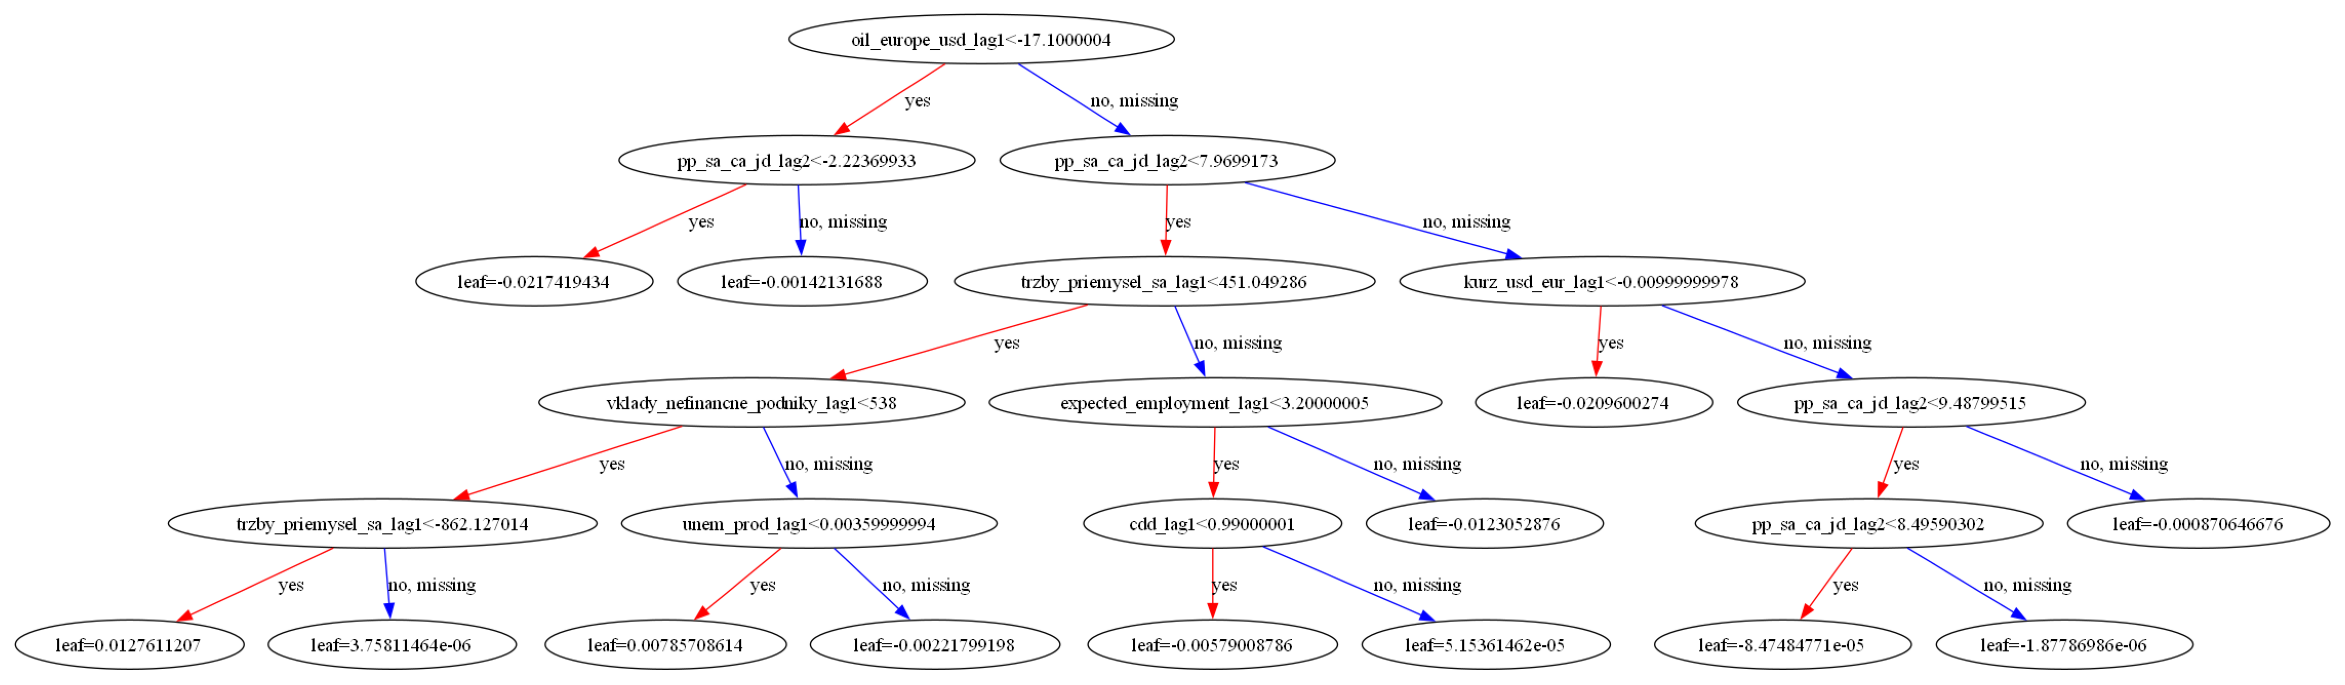

In [118]:
#graficke zobrazenie stromu
from xgboost import plot_tree
import matplotlib.pyplot as plt

plot_tree(xgb_model, num_trees=last_tree)
fig = plt.gcf()
fig.set_size_inches(30, 15)

In [119]:
#Pocet listov a vnutornych uzlov pre kazdy strom
tree_summary = trees_df.groupby("Tree").agg(
    n_nodes=("Node", "count"),
    n_leaves=("Feature", lambda x: (x == "Leaf").sum()),
).reset_index()

# pre binarny strom: n_splits = n_leaves - 1
tree_summary["n_splits"] = tree_summary["n_leaves"] - 1

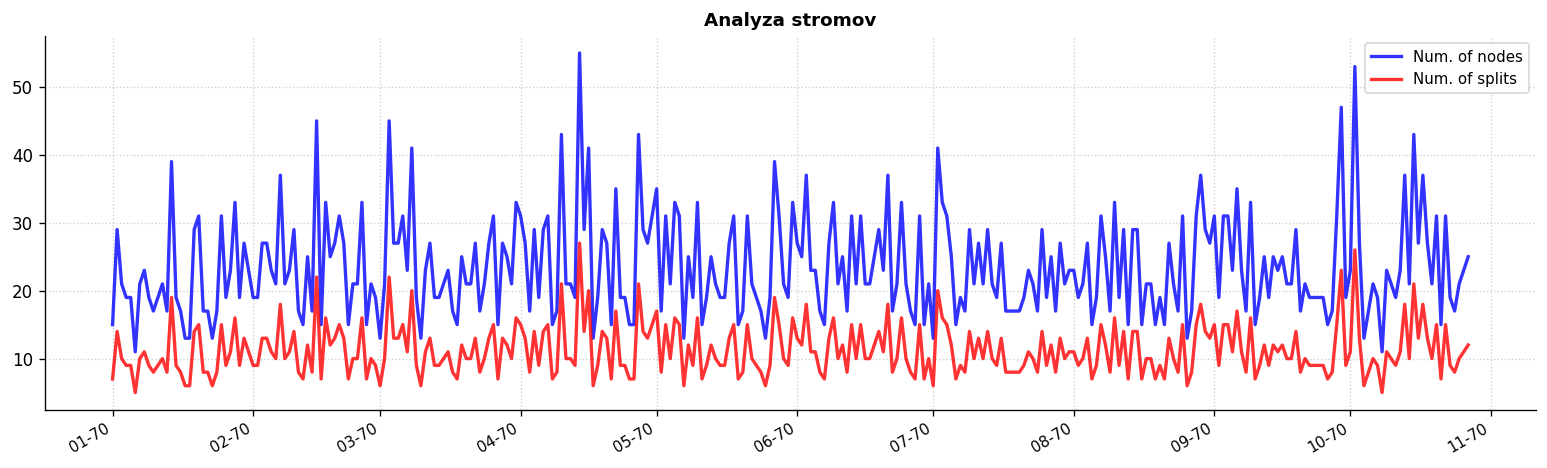

In [122]:
Y_axis = [tree_summary["n_nodes"],tree_summary["n_splits"]]
X_axis = [tree_summary["Tree"]] * len(Y_axis)
labels = ["Num. of nodes", "Num. of splits"] * len(Y_axis)
titles = ["Analyza stromov"]
colors = ["#0000FF", "#FF0000"] * len(Y_axis)
linestyles = ["-"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.8] * len(Y_axis)
fig_size = [13,4]
num_rows = 1
num_cols = 1
curves_per_plot = 3

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, curves_per_plot)

In [60]:
#Zakladna statistika - kolko stromov ma 0, 1, 2+ deleni
split_distribution = tree_summary["n_splits"].value_counts().sort_index()
print("Rozdelenie poctu deleni naprieč stromami:")
print(split_distribution)

n_trivial = (tree_summary["n_splits"] == 0).sum()
n_single_split = (tree_summary["n_splits"] > 1).sum()
n_multi_split = (tree_summary["n_splits"] > 10).sum()

print(f"\nStromy bez delenia (len 1 list):       {n_trivial}")
print(f"Stromy s viac ako 1 delenim (3+ listy):    {n_single_split}")
print(f"Stromy s viac ako 10 delenim (21+ listy): {n_multi_split}")


Rozdelenie poctu deleni naprieč stromami:
n_splits
5      2
6     12
7     25
8     38
9     37
10    44
11    21
12    17
13    27
14    18
15    20
16    15
17     5
18     5
19     1
20     5
21     3
22     1
23     2
26     2
Name: count, dtype: int64

Stromy bez delenia (len 1 list):       0
Stromy s viac ako 1 delenim (3+ listy):    300
Stromy s viac ako 10 delenim (21+ listy): 142


In [74]:
#ktore konkretne stromy maju viac ako 1 delenie
trees_with_multi_splits = tree_summary[tree_summary["n_splits"] > 1].sort_values(
    "n_splits", ascending=False
)
print("\nStromy s viac ako 1 delenim (zoradene podla poctu deleni):")
print(trees_with_multi_splits)


Stromy s viac ako 1 delenim (zoradene podla poctu deleni):
     Tree  n_nodes  n_leaves  n_splits
274   274       53        27        26
103   103       53        27        26
61     61       47        24        23
271   271       47        24        23
45     45       45        23        22
..    ...      ...       ...       ...
181   181       13         7         6
237   237       13         7         6
22     22       13         7         6
280   280       11         6         5
5       5       11         6         5

[300 rows x 4 columns]


In [75]:
# Priemerny pocet deleni cez cely ansambel - rychly diagnosticky ukazovatel
avg_splits = tree_summary["n_splits"].mean()
pct_trivial = (n_trivial / len(tree_summary)) * 100
print(f"\nPriemerny pocet deleni na strom: {avg_splits:.2f}")
print(f"Podiel trivialnych (nerozdelenych) stromov: {pct_trivial:.1f}%")


Priemerny pocet deleni na strom: 11.30
Podiel trivialnych (nerozdelenych) stromov: 0.0%
